# Marine Debris Side-Scan Sonar — YOLO11s Training

This notebook trains the five-class detector on `production_balanced_v1`, reports dataset and model statistics, evaluates the held-out test split, previews detections, and packages the trained weights.

**Before running:** attach the Kaggle dataset `faaizhussain/marine-sonar-balanced-v1`, choose a GPU accelerator, and run all cells in order. A T4/P100-class GPU is suitable. The default run uses all 9,356 training images for up to 100 epochs with early stopping.

Classes: `pipeline`, `shipwreck`, `mine_cylinder`, `ghost_net`, `crab_pot`. The test split has no pipeline instances, so it cannot measure held-out pipeline AP.

In [1]:
%pip install -q ultralytics==8.4.164

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
import random
import shutil
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import FileLink, display
from PIL import Image, ImageDraw

os.environ['YOLO_CONFIG_DIR'] = '/kaggle/working/ultralytics_config'
sns.set_theme(style='whitegrid', context='notebook')

SEED = 26057
random.seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ['pipeline', 'shipwreck', 'mine_cylinder', 'ghost_net', 'crab_pot']
COLORS = ['#39A0ED', '#FFB703', '#E63946', '#57CC99', '#9B5DE5']
WEIGHTS = 'yolo11s.pt'
EPOCHS = 100
IMAGE_SIZE = 640
BATCH = -1  # Ultralytics auto-selects a batch size for the available GPU memory
PATIENCE = 20
WORKERS = 4
RUN_ROOT = Path('/kaggle/working/sonar_training')
RUN_NAME = 'yolo11s_balanced_v1'

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    raise RuntimeError('Enable a GPU accelerator in Kaggle Notebook settings before training.')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Locate and validate the dataset

Kaggle has used two input mount layouts. This cell accepts either one and writes a runtime YAML with the detected absolute path. Empty label files are valid background/control images.

In [3]:
candidates = [
    Path('/kaggle/input/datasets/faaizhussain/marine-sonar-balanced-v1/production_balanced_v1'),
    Path('/kaggle/input/marine-sonar-balanced-v1/production_balanced_v1'),
]
DATASET_ROOT = next((p for p in candidates if (p / 'manifest.jsonl').exists()), None)
if DATASET_ROOT is None:
    matches = list(Path('/kaggle/input').glob('**/production_balanced_v1/manifest.jsonl'))
    if matches:
        DATASET_ROOT = matches[0].parent
if DATASET_ROOT is None:
    raise FileNotFoundError(
        'production_balanced_v1 was not found. Attach the marine-sonar-balanced-v1 dataset.'
    )

required_files = ['manifest.jsonl', 'balance_report.json']
for relative in required_files:
    if not (DATASET_ROOT / relative).is_file():
        raise FileNotFoundError(DATASET_ROOT / relative)
for split in ['train', 'val', 'test']:
    for kind in ['images', 'labels']:
        if not (DATASET_ROOT / kind / split).is_dir():
            raise FileNotFoundError(DATASET_ROOT / kind / split)

runtime_yaml = Path('/kaggle/working/sonar_dataset.yaml')
runtime_config = {
    'path': str(DATASET_ROOT),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': dict(enumerate(CLASS_NAMES)),
}
runtime_yaml.write_text(yaml.safe_dump(runtime_config, sort_keys=False), encoding='utf-8')
print('Dataset root:', DATASET_ROOT)
print(runtime_yaml.read_text())

Dataset root: /kaggle/input/datasets/faaizhussain/marine-sonar-balanced-v1/production_balanced_v1
path: /kaggle/input/datasets/faaizhussain/marine-sonar-balanced-v1/production_balanced_v1
train: images/train
val: images/val
test: images/test
names:
  0: pipeline
  1: shipwreck
  2: mine_cylinder
  3: ghost_net
  4: crab_pot



In [4]:
with (DATASET_ROOT / 'manifest.jsonl').open(encoding='utf-8') as handle:
    manifest = pd.DataFrame(json.loads(line) for line in handle if line.strip())
with (DATASET_ROOT / 'balance_report.json').open(encoding='utf-8') as handle:
    balance_report = json.load(handle)

manifest['is_positive'] = manifest['instances'].gt(0)
manifest['is_negative'] = ~manifest['is_positive']
split_order = ['train', 'val', 'test']

structure_rows = []
for split in split_order:
    image_files = [p for p in (DATASET_ROOT / 'images' / split).iterdir() if p.is_file()]
    label_files = [p for p in (DATASET_ROOT / 'labels' / split).iterdir() if p.is_file()]
    expected = manifest.loc[manifest['split'].eq(split)]
    structure_rows.append({
        'split': split,
        'images_on_disk': len(image_files),
        'labels_on_disk': len(label_files),
        'manifest_images': len(expected),
        'positive_images': int(expected['is_positive'].sum()),
        'negative_images': int(expected['is_negative'].sum()),
        'instances': int(expected['instances'].sum()),
    })
structure = pd.DataFrame(structure_rows).set_index('split')
display(structure)
assert (structure['images_on_disk'] == structure['manifest_images']).all()
assert (structure['labels_on_disk'] == structure['manifest_images']).all()
print(f'Total images: {len(manifest):,}')

,images_on_disk,labels_on_disk,manifest_images,positive_images,negative_images,instances
split,,,,,,
train,9356,9356,9356,6973,2383,9499
val,2219,2219,2219,1571,648,2364
test,2432,2432,2432,1989,443,3092


Total images: 14,007


## Dataset statistics

These plots expose the split size, training class balance, source composition, and positive/background mix before training.

,all_instances
pipeline,1321
shipwreck,2623
mine_cylinder,668
ghost_net,4294
crab_pot,6049


,pipeline,shipwreck,mine_cylinder,ghost_net,crab_pot
train,"1,278","1,627",513,"3,034","3,047"
val,43,176,74,630,"1,441"
test,0,820,81,630,"1,561"


split,train,val,test
source,,,
drishti,2976,203,536
ghostnet_v3_6000,4200,900,900
ghostvision,2180,1116,996


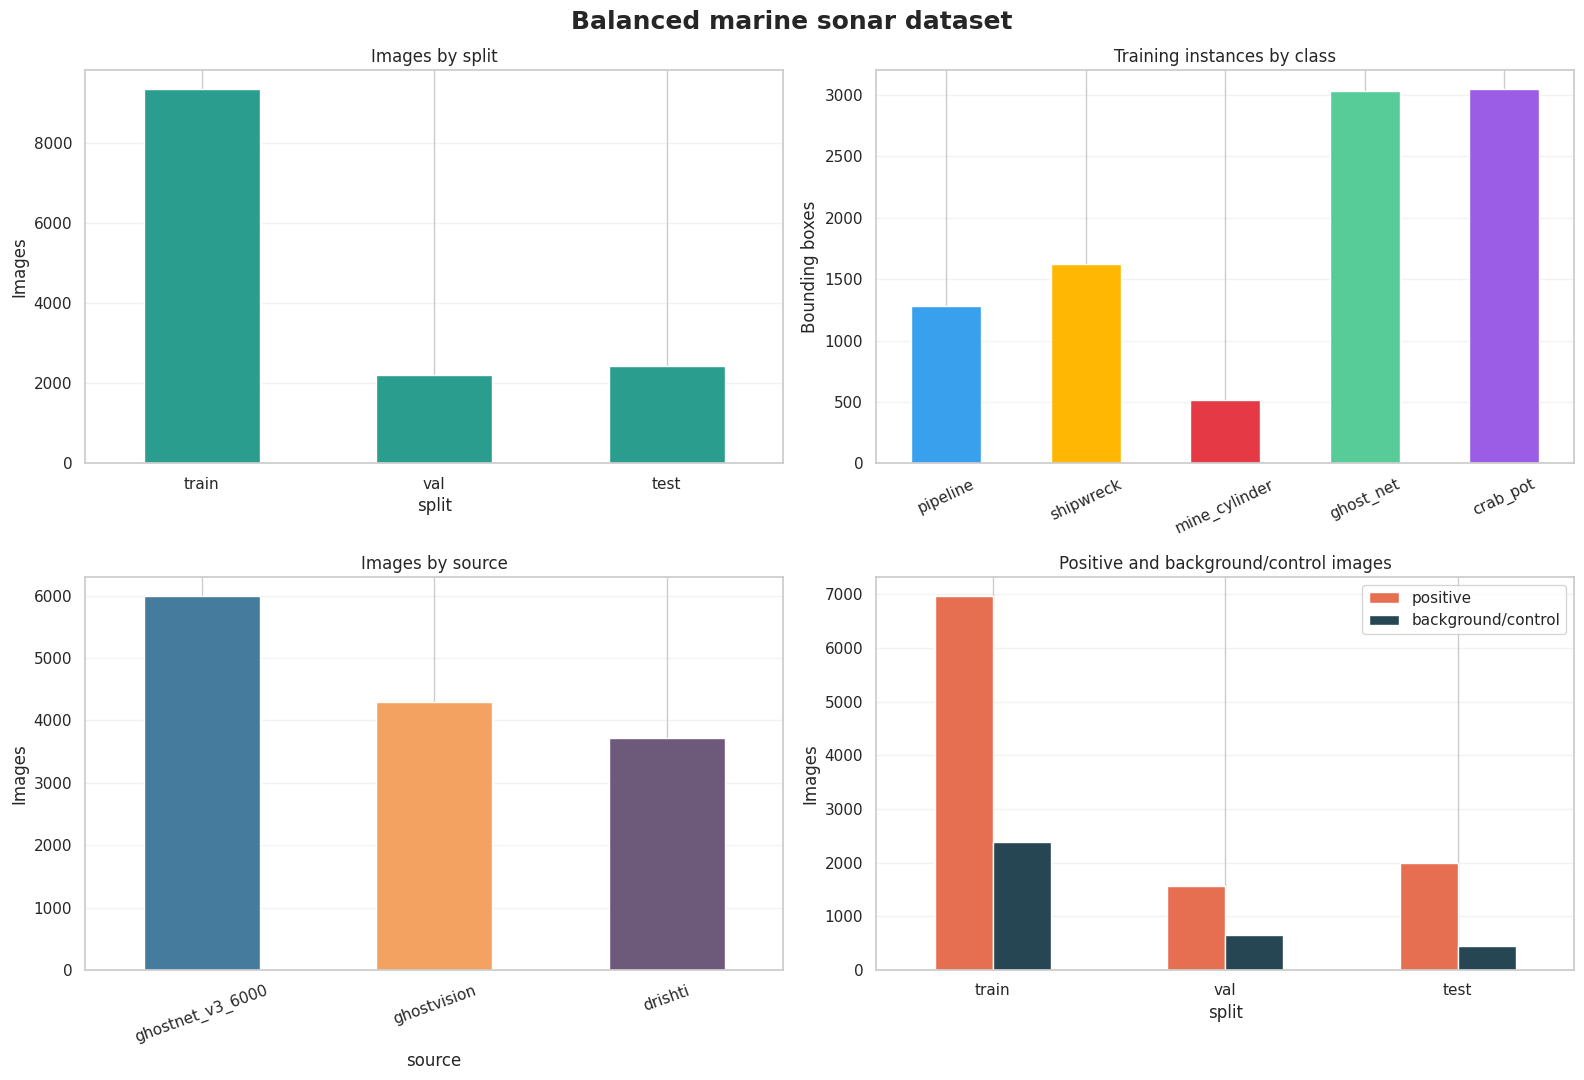

In [5]:
balanced = balance_report['balanced']
class_by_split = pd.DataFrame(balanced['split_class_instances']).T.reindex(split_order)
class_by_split = class_by_split.reindex(columns=CLASS_NAMES)
source_counts = manifest['source'].value_counts()
split_counts = manifest['split'].value_counts().reindex(split_order)
pos_neg = manifest.groupby('split')[['is_positive', 'is_negative']].sum().reindex(split_order)

display(pd.DataFrame({'all_instances': balanced['class_instances']}))
display(class_by_split.style.format('{:,.0f}').set_caption('Instances by split and class'))
display(pd.crosstab(manifest['source'], manifest['split']).reindex(columns=split_order, fill_value=0))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
split_counts.plot.bar(ax=axes[0, 0], color='#2A9D8F', title='Images by split')
axes[0, 0].set_ylabel('Images')
axes[0, 0].tick_params(axis='x', rotation=0)

class_by_split.loc['train'].plot.bar(ax=axes[0, 1], color=COLORS, title='Training instances by class')
axes[0, 1].set_ylabel('Bounding boxes')
axes[0, 1].tick_params(axis='x', rotation=25)

source_counts.plot.bar(ax=axes[1, 0], color=['#457B9D', '#F4A261', '#6D597A'], title='Images by source')
axes[1, 0].set_ylabel('Images')
axes[1, 0].tick_params(axis='x', rotation=20)

pos_neg.rename(columns={'is_positive': 'positive', 'is_negative': 'background/control'}).plot.bar(
    ax=axes[1, 1], color=['#E76F51', '#264653'], title='Positive and background/control images'
)
axes[1, 1].set_ylabel('Images')
axes[1, 1].tick_params(axis='x', rotation=0)

for ax in axes.flat:
    ax.grid(axis='y', alpha=0.25)
fig.suptitle('Balanced marine sonar dataset', fontsize=18, fontweight='bold')
fig.tight_layout()
distribution_plot = Path('/kaggle/working/dataset_distribution.png')
fig.savefig(distribution_plot, dpi=160, bbox_inches='tight')
plt.show()

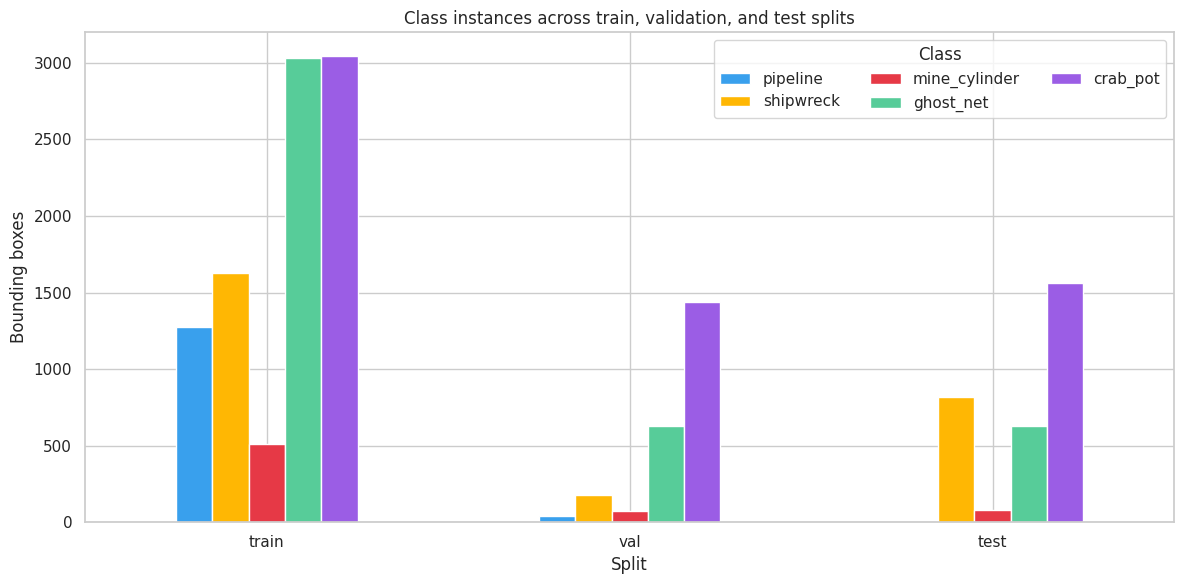

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
class_by_split.plot.bar(ax=ax, color=COLORS)
ax.set_title('Class instances across train, validation, and test splits')
ax.set_xlabel('Split')
ax.set_ylabel('Bounding boxes')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Class', ncol=3)
fig.tight_layout()
class_split_plot = Path('/kaggle/working/class_instances_by_split.png')
fig.savefig(class_split_plot, dpi=160, bbox_inches='tight')
plt.show()

## Annotated training examples

This samples two images containing each class and redraws their YOLO labels. It is a quick visual check, not a release audit.

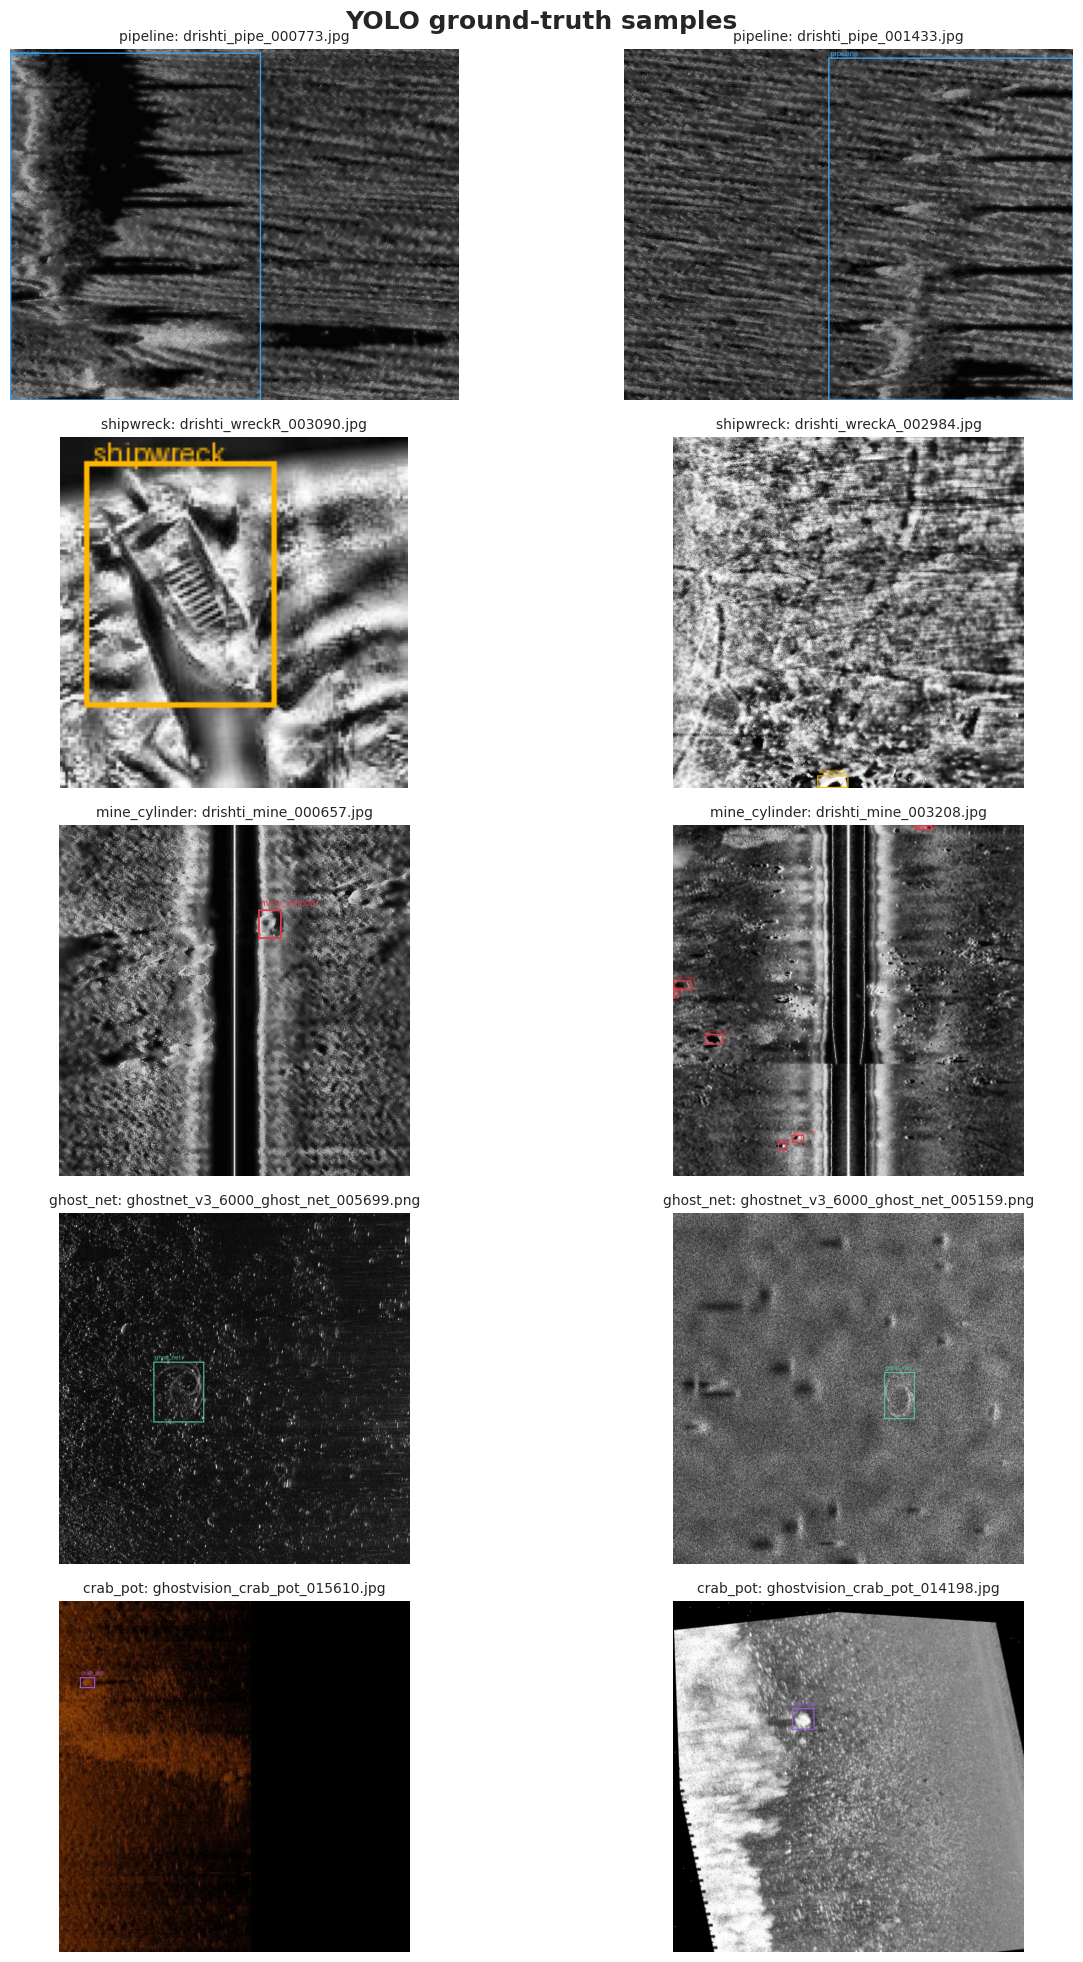

In [7]:
def read_yolo_labels(label_path):
    rows = []
    text = label_path.read_text(encoding='utf-8').strip()
    for line in text.splitlines() if text else []:
        values = line.split()
        if len(values) >= 5:
            rows.append((int(float(values[0])), *map(float, values[1:5])))
    return rows

def draw_labels(image_path, label_path):
    image = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(image)
    width, height = image.size
    for class_id, xc, yc, bw, bh in read_yolo_labels(label_path):
        x1, y1 = (xc - bw / 2) * width, (yc - bh / 2) * height
        x2, y2 = (xc + bw / 2) * width, (yc + bh / 2) * height
        color = COLORS[class_id]
        draw.rectangle((x1, y1, x2, y2), outline=color, width=max(2, width // 250))
        draw.text((x1 + 3, max(0, y1 - 14)), CLASS_NAMES[class_id], fill=color)
    return image

samples_by_class = {class_id: [] for class_id in range(len(CLASS_NAMES))}
train_rows = manifest.loc[(manifest['split'] == 'train') & manifest['is_positive']].sample(
    frac=1, random_state=SEED
)
for row in train_rows.itertuples():
    label_path = DATASET_ROOT / row.label
    present = {item[0] for item in read_yolo_labels(label_path)}
    for class_id in present:
        if class_id in samples_by_class and len(samples_by_class[class_id]) < 2:
            samples_by_class[class_id].append((DATASET_ROOT / row.image, label_path))
    if all(len(items) >= 2 for items in samples_by_class.values()):
        break

fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(14, 20))
for class_id, class_name in enumerate(CLASS_NAMES):
    for column in range(2):
        ax = axes[class_id, column]
        if column < len(samples_by_class[class_id]):
            image_path, label_path = samples_by_class[class_id][column]
            ax.imshow(draw_labels(image_path, label_path))
            ax.set_title(f'{class_name}: {image_path.name}', fontsize=10)
        else:
            ax.text(0.5, 0.5, 'No sample found', ha='center', va='center')
        ax.axis('off')
fig.suptitle('YOLO ground-truth samples', fontsize=18, fontweight='bold')
fig.tight_layout()
sample_plot = Path('/kaggle/working/annotated_ground_truth_samples.png')
fig.savefig(sample_plot, dpi=150, bbox_inches='tight')
plt.show()

## Train YOLO11s

The run uses pretrained YOLO11s weights, 640-pixel inputs, automatic batch sizing, mixed precision, and early stopping. Kaggle sessions have time limits; completed checkpoints remain in `/kaggle/working/sonar_training`.

In [8]:
from ultralytics import YOLO

model = YOLO(WEIGHTS)
train_result = model.train(
    data=str(runtime_yaml),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH,
    device=0,
    workers=WORKERS,
    patience=PATIENCE,
    pretrained=True,
    seed=SEED,
    deterministic=True,
    amp=True,
    cache=False,
    close_mosaic=10,
    project=str(RUN_ROOT),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
    verbose=True,
)
RUN_DIR = RUN_ROOT / RUN_NAME
BEST_WEIGHTS = RUN_DIR / 'weights' / 'best.pt'
if not BEST_WEIGHTS.exists():
    raise FileNotFoundError(f'Training ended without {BEST_WEIGHTS}')
print('Best weights:', BEST_WEIGHTS)

WARNING ⚠️ user config directory '/kaggle/working/ultralytics_config/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
New https://pypi.org/project/ultralytics/8.4.165 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.164 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/sonar_dataset.yaml, degr

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


      2/100      4.65G      1.478      1.621      1.466          5        640: 100% ━━━━━━━━━━━━ 669/669 4.9it/s 2:17
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 80/80 5.1it/s 15.7s
                   all       2219       2364      0.477      0.243      0.201      0.105

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      4.65G      1.612      1.807      1.553          5        640: 100% ━━━━━━━━━━━━ 669/669 5.2it/s 2:09
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 80/80 5.0it/s 16.1s
                   all       2219       2364      0.322      0.243      0.233       0.13

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      4.65G       1.63      1.784      1.589          8        640: 100% ━━━━━━━━━━━━ 669/669 5.3it/s 2:07
                 Class     Images  Instances      Box(

## Learning curves and validation plots

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
61,62,8929.13,0.92529,0.68559,1.08874,0.70965,0.47683,0.47746,0.30725,1.33393,4.32156,1.11471,0.011883,0.003961,0.011883,0.003961,0.011883,0.003961,0.011883,0.003961
62,63,9072.37,0.91944,0.68357,1.08941,0.67223,0.46553,0.46606,0.30275,1.33892,3.94464,1.12663,0.011586,0.003862,0.011586,0.003862,0.011586,0.003862,0.011586,0.003862
63,64,9215.41,0.90352,0.67106,1.08571,0.69252,0.46332,0.49350,0.31427,1.32273,4.07687,1.11952,0.011289,0.003763,0.011289,0.003763,0.011289,0.003763,0.011289,0.003763
64,65,9358.59,0.90966,0.66190,1.08307,0.67119,0.47477,0.48898,0.31472,1.31896,4.31446,1.12010,0.010992,0.003664,0.010992,0.003664,0.010992,0.003664,0.010992,0.003664
65,66,9501.98,0.90810,0.66252,1.08389,0.69316,0.47284,0.47063,0.30807,1.34623,4.65383,1.12206,0.010695,0.003565,0.010695,0.003565,0.010695,0.003565,0.010695,0.003565


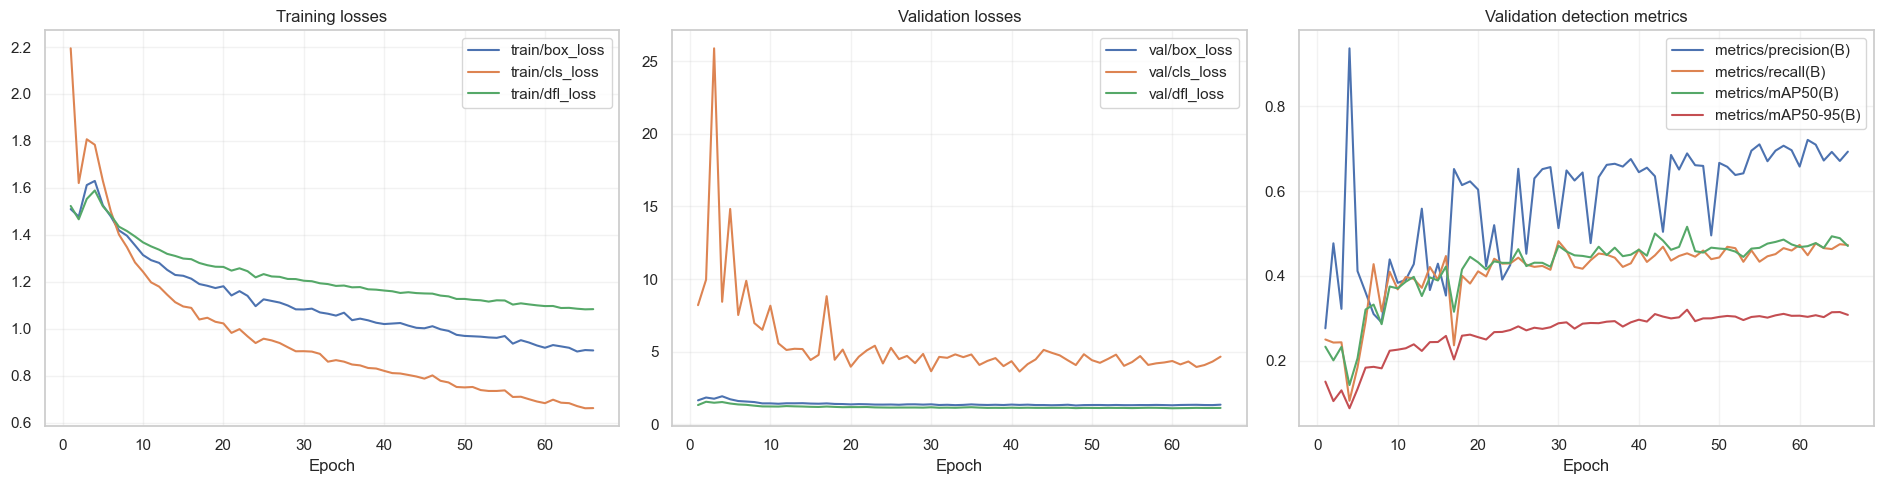

Best validation mAP50-95: 0.3203 at epoch 46


In [9]:
results_csv = RUN_DIR / 'results.csv'
history = pd.read_csv(results_csv)
history.columns = history.columns.str.strip()
display(history.tail())

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
loss_columns = ['train/box_loss', 'train/cls_loss', 'train/dfl_loss']
val_loss_columns = ['val/box_loss', 'val/cls_loss', 'val/dfl_loss']
metric_columns = ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']
history.plot(x='epoch', y=[c for c in loss_columns if c in history], ax=axes[0], title='Training losses')
history.plot(x='epoch', y=[c for c in val_loss_columns if c in history], ax=axes[1], title='Validation losses')
history.plot(x='epoch', y=[c for c in metric_columns if c in history], ax=axes[2], title='Validation detection metrics')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.25)
fig.tight_layout()
learning_plot = Path('/kaggle/working/learning_curves.png')
fig.savefig(learning_plot, dpi=160, bbox_inches='tight')
plt.show()

best_metric = 'metrics/mAP50-95(B)'
if best_metric in history:
    best_row = history.loc[history[best_metric].idxmax()]
    print(f"Best validation mAP50-95: {best_row[best_metric]:.4f} at epoch {int(best_row['epoch'])}")

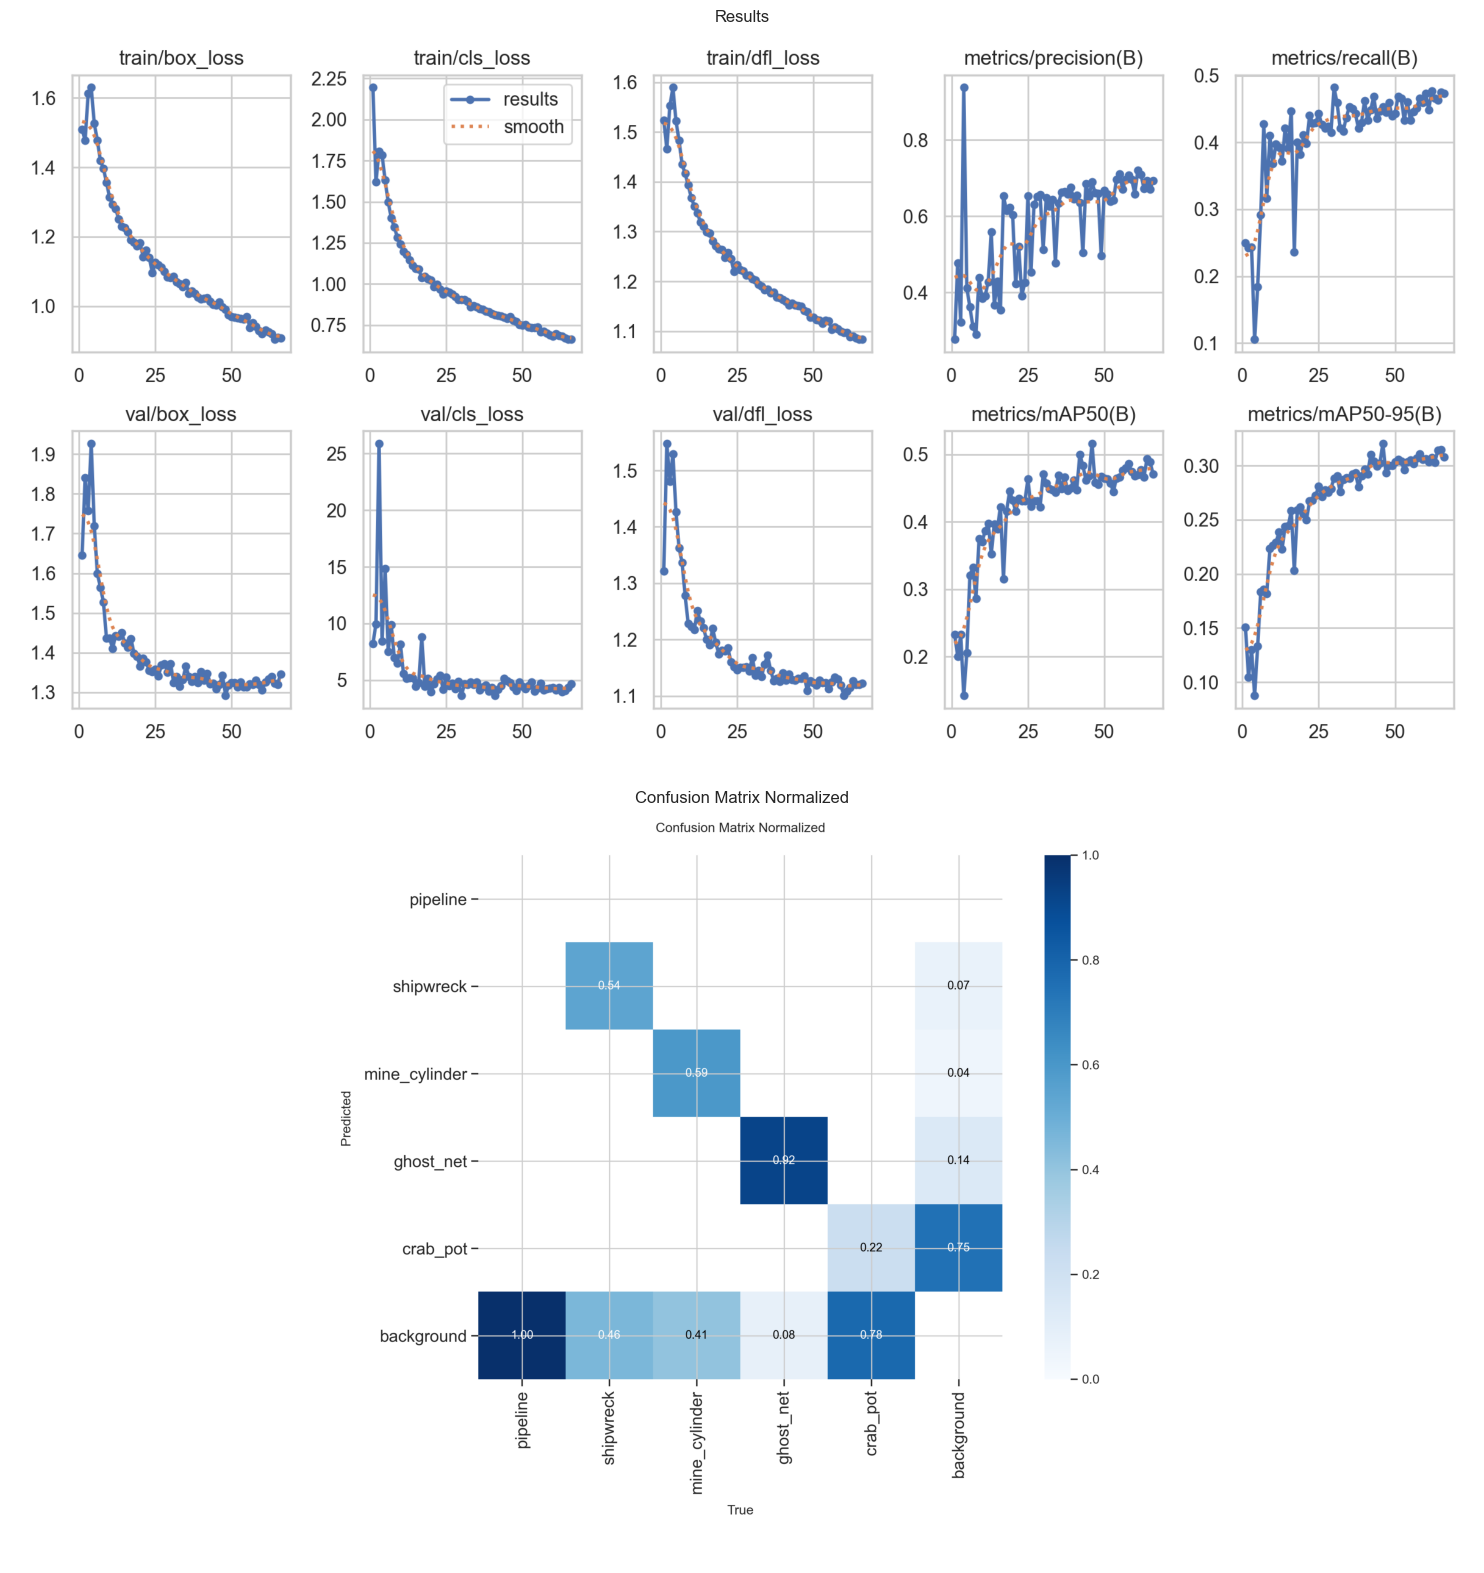

In [10]:
generated_plots = [
    RUN_DIR / 'results.png',
    RUN_DIR / 'confusion_matrix_normalized.png',
    RUN_DIR / 'PR_curve.png',
    RUN_DIR / 'F1_curve.png',
]
available_plots = [p for p in generated_plots if p.exists()]
if available_plots:
    fig, axes = plt.subplots(len(available_plots), 1, figsize=(15, 8 * len(available_plots)))
    axes = np.atleast_1d(axes)
    for ax, plot_path in zip(axes, available_plots):
        ax.imshow(Image.open(plot_path))
        ax.set_title(plot_path.stem.replace('_', ' ').title())
        ax.axis('off')
    fig.tight_layout()
    plt.show()

## Held-out test evaluation

The following metrics come from the untouched test split. Pipeline has zero test instances in this release, so its test AP is unavailable and should not be reported as validated performance.

In [11]:
best_model = YOLO(str(BEST_WEIGHTS))
test_metrics = best_model.val(
    data=str(runtime_yaml),
    split='test',
    imgsz=IMAGE_SIZE,
    batch=16,
    device=0,
    workers=WORKERS,
    plots=True,
    project=str(RUN_ROOT),
    name='test_evaluation',
    exist_ok=True,
)

overall_metrics = {key: float(value) for key, value in test_metrics.results_dict.items()}
overall_metrics['weights'] = str(BEST_WEIGHTS)
overall_metrics['test_images'] = int((manifest['split'] == 'test').sum())
overall_metrics_path = Path('/kaggle/working/test_metrics_overall.json')
overall_metrics_path.write_text(json.dumps(overall_metrics, indent=2), encoding='utf-8')
display(pd.DataFrame([overall_metrics]).T.rename(columns={0: 'value'}))

Ultralytics 8.4.164 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 100 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 22.4±14.6 MB/s, size: 198.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/faaizhussain/marine-sonar-balanced-v1/production_balanced_v1/labels/test... 2432 images, 443 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2432/2432 201.8it/s 12.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/faaizhussain/marine-sonar-balanced-v1/production_balanced_v1/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 152/152 4.2it/s 35.8s
                   all       2432       3092      0.555      0.539      0.524      0.342
             shipwrec

,value
metrics/precision(B),0.554762
metrics/recall(B),0.539069
metrics/mAP50(B),0.524465
metrics/mAP50-95(B),0.341931
fitness,0.341931
weights,/kaggle/working/sonar_training/yolo11s_balance...
test_images,2432


,class_id,class,test_instances,precision,recall,mAP50,mAP50-95
0,0,pipeline,0,N/A,N/A,N/A,N/A
1,1,shipwreck,820,0.459,0.549,0.497,0.280
2,2,mine_cylinder,81,0.550,0.556,0.482,0.213
3,3,ghost_net,630,0.878,0.898,0.929,0.811
4,4,crab_pot,1561,0.333,0.154,0.189,0.064


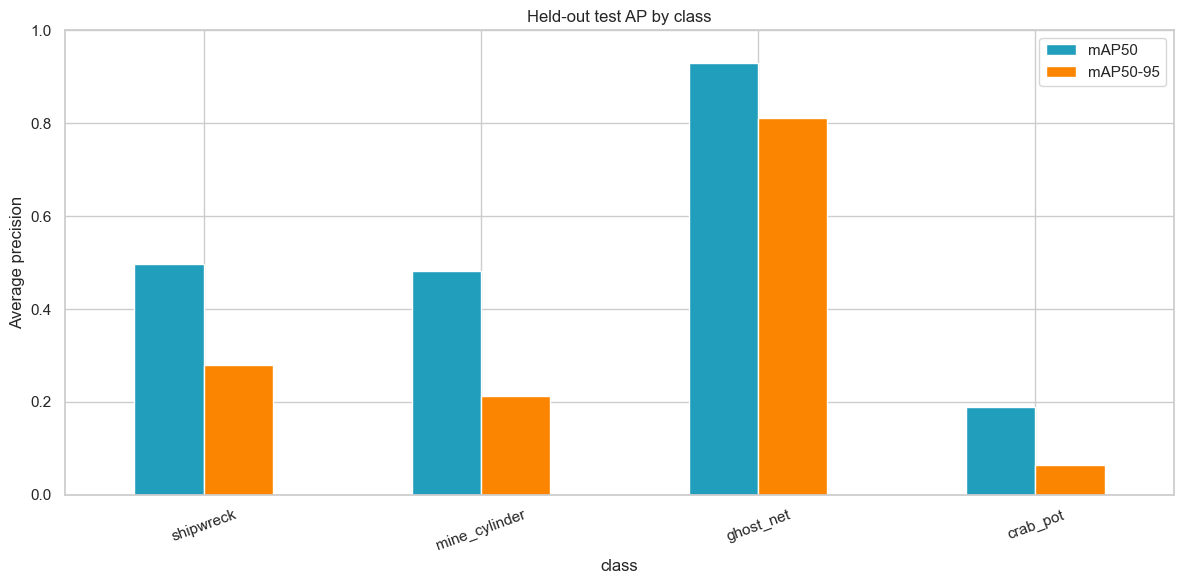

In [12]:
box = test_metrics.box
evaluated_ids = [int(index) for index in np.asarray(box.ap_class_index).tolist()]
per_class_rows = []
for position, class_id in enumerate(evaluated_ids):
    per_class_rows.append({
        'class_id': class_id,
        'class': CLASS_NAMES[class_id],
        'test_instances': int(class_by_split.loc['test', CLASS_NAMES[class_id]]),
        'precision': float(np.asarray(box.p)[position]),
        'recall': float(np.asarray(box.r)[position]),
        'mAP50': float(np.asarray(box.ap50)[position]),
        'mAP50-95': float(np.asarray(box.ap)[position]),
    })
per_class = pd.DataFrame(per_class_rows)
for class_id, class_name in enumerate(CLASS_NAMES):
    if class_id not in evaluated_ids:
        per_class.loc[len(per_class)] = [
            class_id, class_name, int(class_by_split.loc['test', class_name]), np.nan, np.nan, np.nan, np.nan
        ]
per_class = per_class.sort_values('class_id').reset_index(drop=True)
per_class_path = Path('/kaggle/working/test_metrics_per_class.csv')
per_class.to_csv(per_class_path, index=False)
display(per_class.style.format({
    'precision': '{:.3f}', 'recall': '{:.3f}', 'mAP50': '{:.3f}', 'mAP50-95': '{:.3f}'
}, na_rep='N/A'))

plot_data = per_class.dropna(subset=['mAP50', 'mAP50-95']).set_index('class')[['mAP50', 'mAP50-95']]
ax = plot_data.plot.bar(figsize=(12, 6), color=['#219EBC', '#FB8500'])
ax.set_ylim(0, 1)
ax.set_ylabel('Average precision')
ax.set_title('Held-out test AP by class')
ax.tick_params(axis='x', rotation=20)
fig = ax.get_figure()
fig.tight_layout()
per_class_plot = Path('/kaggle/working/test_ap_by_class.png')
fig.savefig(per_class_plot, dpi=160, bbox_inches='tight')
plt.show()

## Prediction preview

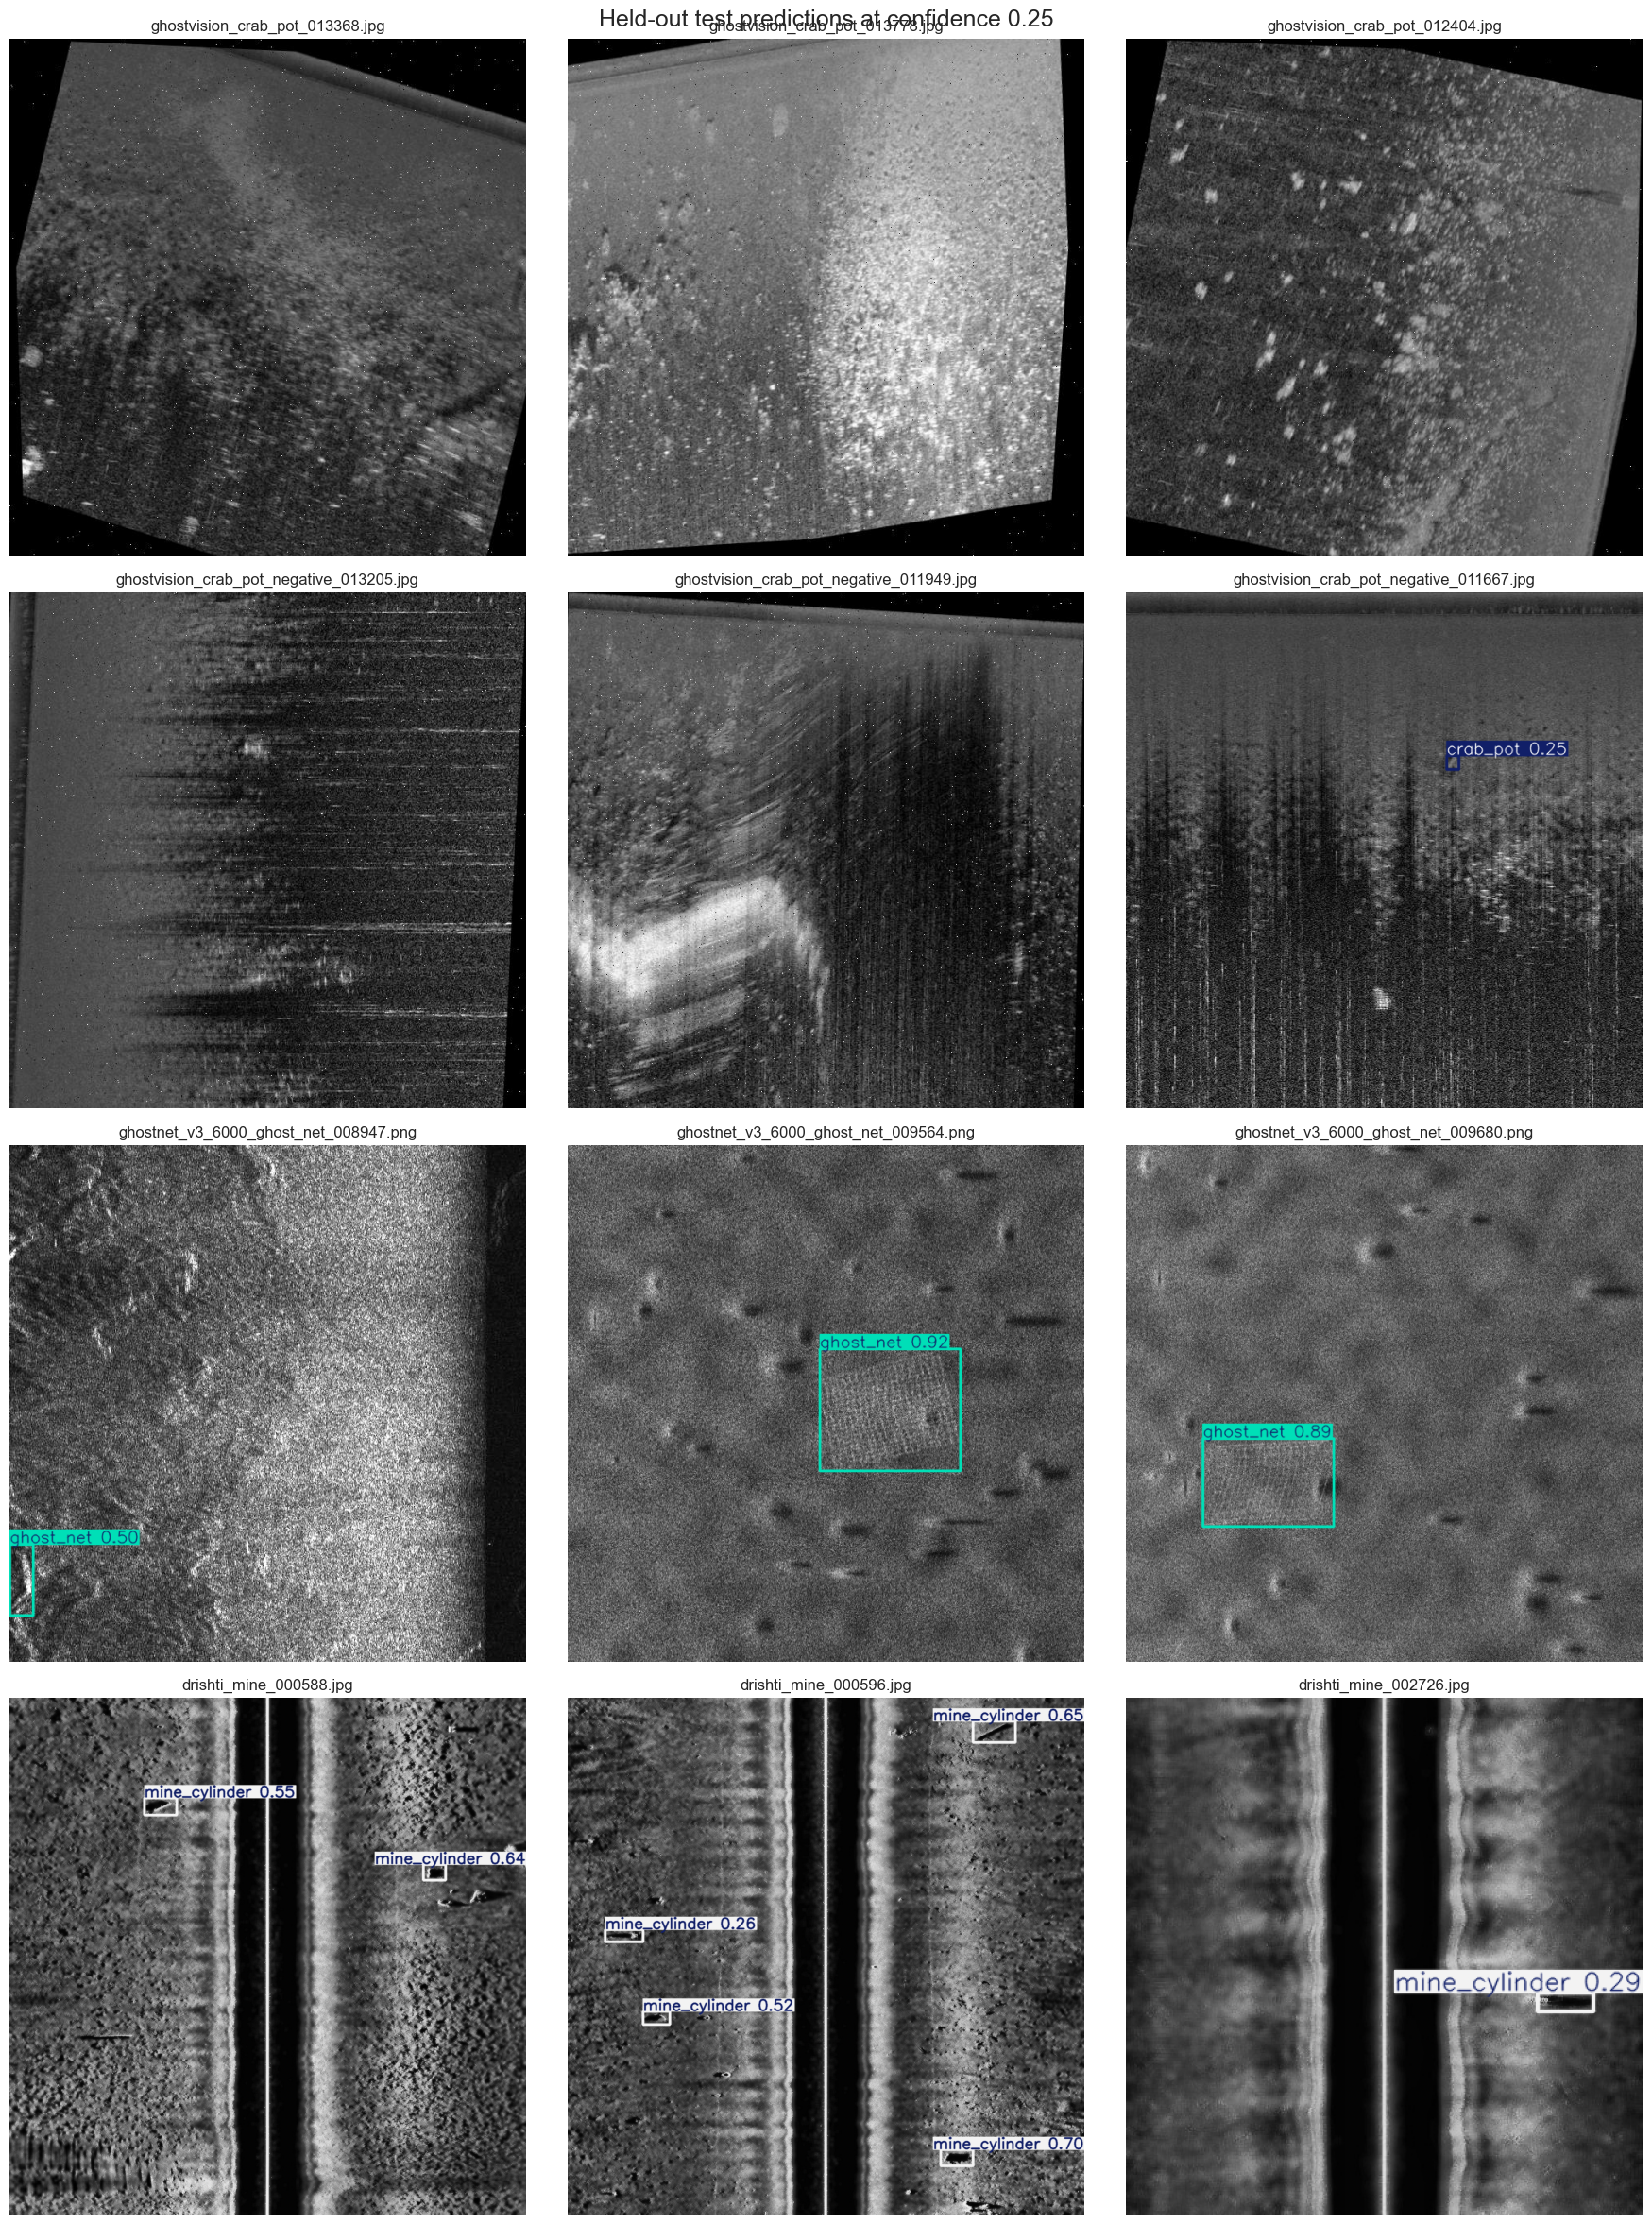

In [13]:
preview_groups = manifest.loc[manifest['split'].eq('test')].groupby('source_subset')
preview_rows = pd.concat([
    group.sample(min(3, len(group)), random_state=SEED)
    for _, group in preview_groups
]).head(12)
preview_paths = [str(DATASET_ROOT / relative) for relative in preview_rows['image']]
predictions = best_model.predict(
    source=preview_paths, imgsz=IMAGE_SIZE, conf=0.25, device=0, verbose=False
)
columns = 3
rows = int(np.ceil(len(predictions) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(18, 6 * rows))
axes = np.atleast_1d(axes).ravel()
for ax, result in zip(axes, predictions):
    rendered = result.plot()[:, :, ::-1]
    ax.imshow(rendered)
    ax.set_title(Path(result.path).name)
    ax.axis('off')
for ax in axes[len(predictions):]:
    ax.axis('off')
fig.suptitle('Held-out test predictions at confidence 0.25', fontsize=18, fontweight='bold')
fig.tight_layout()
prediction_plot = Path('/kaggle/working/test_prediction_preview.png')
fig.savefig(prediction_plot, dpi=150, bbox_inches='tight')
plt.show()

## Export model and reports

The dashboard should use the exported `.pt` file. ONNX export is optional and disabled because the current dashboard uses Ultralytics PyTorch inference.

In [14]:
EXPORT_ONNX = False
exported_weights = Path('/kaggle/working/sonar_yolo11s_balanced_v1_best.pt')
shutil.copy2(BEST_WEIGHTS, exported_weights)

onnx_path = None
if EXPORT_ONNX:
    onnx_path = Path(best_model.export(format='onnx', imgsz=IMAGE_SIZE, simplify=True))

summary = {
    'dataset_root': str(DATASET_ROOT),
    'dataset_images': int(len(manifest)),
    'split_images': {split: int(count) for split, count in split_counts.items()},
    'train_class_instances': {name: int(value) for name, value in class_by_split.loc['train'].items()},
    'model': WEIGHTS,
    'epochs_requested': EPOCHS,
    'image_size': IMAGE_SIZE,
    'seed': SEED,
    'test_metrics': overall_metrics,
    'known_limitations': balance_report.get('remaining_limitations', []),
}
summary_path = Path('/kaggle/working/training_summary.json')
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')

bundle_path = Path('/kaggle/working/marine_sonar_yolo11s_artifacts.zip')
artifact_candidates = [
    exported_weights, summary_path, overall_metrics_path, per_class_path, results_csv,
    distribution_plot, class_split_plot, sample_plot, learning_plot, per_class_plot, prediction_plot,
    RUN_DIR / 'args.yaml', RUN_DIR / 'confusion_matrix.png',
    RUN_DIR / 'confusion_matrix_normalized.png', RUN_DIR / 'PR_curve.png', RUN_DIR / 'F1_curve.png',
]
if onnx_path is not None:
    artifact_candidates.append(onnx_path)
with zipfile.ZipFile(bundle_path, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for artifact in artifact_candidates:
        artifact = Path(artifact)
        if artifact.exists():
            archive.write(artifact, arcname=artifact.name)

print(f'Weights: {exported_weights} ({exported_weights.stat().st_size / 1e6:.1f} MB)')
print(f'Artifact bundle: {bundle_path} ({bundle_path.stat().st_size / 1e6:.1f} MB)')
display(FileLink(str(exported_weights)))
display(FileLink(str(bundle_path)))

Weights: /kaggle/working/sonar_yolo11s_balanced_v1_best.pt (19.2 MB)
Artifact bundle: /kaggle/working/marine_sonar_yolo11s_artifacts.zip (30.8 MB)


/kaggle/working/sonar_yolo11s_balanced_v1_best.pt

/kaggle/working/marine_sonar_yolo11s_artifacts.zip

## Interpretation limits

- The test split contains no pipeline instances, so pipeline test AP is unavailable.
- Ghost-net imagery is synthetic in this release; the model still needs independent real ghost-net evaluation.
- Class appearance and source domain remain correlated, which can inflate same-source performance.
- Source-specific empty labels are not verified negatives for every class.
- Raw YOLO confidence is not calibrated probability. Calibrate thresholds on representative validation data before operational use.
- Inspect the confusion matrix and prediction previews before connecting the weight file to the dashboard.